In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import gmsh
from numba import njit, prange
from scipy.sparse import csr_matrix, diags, lil_matrix
from scipy.sparse.linalg import spsolve, factorized
from tqdm import tqdm
import csv
import logging
import plotly.graph_objects as go
import json
import time
from dash import dcc, html, Dash
from dash.dependencies import Input, Output


# ------------------------------
# 1. Imports and Setup
# ------------------------------

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Define global constants
DISPLACEMENT_THRESHOLD = 1e-10

# ------------------------------
# 2. Utility Functions
# ------------------------------

# @njit
def ricker_wavelet_scalar_numba(frequency, t, time_shift=1.0):
    """
    Generates a normalized Ricker wavelet for a single time value using Numba.

    Parameters:
        frequency (float): Central frequency of the wavelet.
        t (float): Single time value.
        time_shift (float): Time shift to center the wavelet.

    Returns:
        float: Normalized Ricker wavelet value.
    """
    t_shifted = t - time_shift
    pi_f_t = np.pi * frequency * t_shifted
    wave = (1 - 2 * pi_f_t ** 2) * np.exp(-pi_f_t ** 2)

    # Normalize the wavelet
    max_val = np.abs(wave)
    if max_val != 0:
        wave /= max_val

    return wave



@njit(parallel=True)
def elastodynamic_distance_numba(sx, sy, sz, tx, ty, tz, epsilon=1e-8):
    """
    Calculates the Euclidean distance between two points in 3D space with a small epsilon.

    Parameters:
        sx, sy, sz (float): Source point coordinates.
        tx, ty, tz (float): Target point coordinates.
        epsilon (float): Small value to prevent division by zero.

    Returns:
        float: Distance between points plus epsilon.
    """
    dx = sx - tx
    dy = sy - ty
    dz = sz - tz
    return np.sqrt(dx ** 2 + dy ** 2 + dz ** 2) + epsilon

@njit
def elastodynamic_kernel_numba(r, c_p, c_s):
    """
    Computes the elastodynamic kernel between two points.

    Parameters:
        r (float): Distance between points.
        c_p (float): Primary wave speed.
        c_s (float): Secondary wave speed.

    Returns:
        float: Kernel value.
    """
    if r == 0.0:
        return 0.0
    term1 = 1.0 / (4.0 * np.pi * r)
    term2 = ((c_p ** 2 - c_s ** 2) / (c_p ** 2)) * (1.0 / r)
    return term1 * term2

@njit(parallel=True)
def fill_matrix_numba(A, points_3d, c_p, c_s, cutoff=10.0):
    """
    Fills the stiffness matrix A using the elastodynamic kernel with a cutoff distance.

    Parameters:
        A (np.ndarray): Stiffness matrix to be filled.
        points_3d (np.ndarray): Array of node coordinates.
        c_p (float): Primary wave speed.
        c_s (float): Secondary wave speed.
        cutoff (float): Cutoff distance for interactions.

    Returns:
        np.ndarray: Filled stiffness matrix.
    """
    n = points_3d.shape[0]
    for i in prange(n):
        for j in range(n):
            if i != j:
                r = elastodynamic_distance_numba(
                    points_3d[i, 0], points_3d[i, 1], points_3d[i, 2],
                    points_3d[j, 0], points_3d[j, 1], points_3d[j, 2]
                )
                if r < cutoff:
                    A[i, j] = elastodynamic_kernel_numba(r, c_p, c_s)
    return A

def ricker_wavelet_array(frequency, t, time_shift=1.0):
    """
    Generates a normalized Ricker wavelet for an array of time values.

    Parameters:
        frequency (float): Central frequency of the wavelet.
        t (np.ndarray): Array of time values.
        time_shift (float): Time shift to center the wavelet.

    Returns:
        np.ndarray: Normalized Ricker wavelet values.
    """
    wave = np.array([ricker_wavelet_scalar_numba(frequency, ti, time_shift) for ti in t])
    return wave

# ------------------------------
# 3. Mesh Generation
# ------------------------------
import gmsh
import numpy as np
import gmsh
import numpy as np

def generate_mesh(domain_shape, element_size=1.0, refinement=False, mesh_type='triangle'):
    """
    Generates a 2D or 3D mesh using Gmsh.

    Parameters:
        domain_shape (tuple): A tuple specifying the dimensions of the domain, e.g., (width, height) for 2D or (width, height, depth) for 3D.
        element_size (float): Characteristic length of mesh elements.
        refinement (bool): Whether to refine the mesh.
        mesh_type (str): Type of mesh elements to generate ('quadrilateral' or 'triangle').

    Returns:
        tuple: (points_3d, elements) where points_3d are node coordinates and elements define the mesh connectivity.
    """

    gmsh.initialize()
    gmsh.model.add("mesh")

    # Create geometric entities based on domain shape
    if len(domain_shape) == 2:  # 2D domain
        width, height = domain_shape
        p1 = gmsh.model.geo.addPoint(-width / 2, -height / 2, 0, element_size)
        p2 = gmsh.model.geo.addPoint(width / 2, -height / 2, 0, element_size)
        p3 = gmsh.model.geo.addPoint(width / 2, height / 2, 0, element_size)
        p4 = gmsh.model.geo.addPoint(-width / 2, height / 2, 0, element_size)

        l1 = gmsh.model.geo.addLine(p1, p2)
        l2 = gmsh.model.geo.addLine(p2, p3)
        l3 = gmsh.model.geo.addLine(p3, p4)
        l4 = gmsh.model.geo.addLine(p4, p1)

        curve_loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
        gmsh.model.geo.addPlaneSurface([curve_loop])

    elif len(domain_shape) == 3:  # 3D domain
        width, height, depth = domain_shape

        # Example: Create a cube
        p1 = gmsh.model.geo.addPoint(-width / 2, -height / 2, -depth / 2, element_size)
        p2 = gmsh.model.geo.addPoint(width / 2, -height / 2, -depth / 2, element_size)
        p3 = gmsh.model.geo.addPoint(width / 2, height / 2, -depth / 2, element_size)
        p4 = gmsh.model.geo.addPoint(-width / 2, height / 2, -depth / 2, element_size)
        p5 = gmsh.model.geo.addPoint(-width / 2, -height / 2, depth / 2, element_size)
        p6 = gmsh.model.geo.addPoint(width / 2, -height / 2, depth / 2, element_size)
        p7 = gmsh.model.geo.addPoint(width / 2, height / 2, depth / 2, element_size)
        p8 = gmsh.model.geo.addPoint(-width / 2, height / 2, depth / 2, element_size)

        # Create lines for the edges of the cube
        l1 = gmsh.model.geo.addLine(p1, p2)
        l2 = gmsh.model.geo.addLine(p2, p3)
        l3 = gmsh.model.geo.addLine(p3, p4)
        l4 = gmsh.model.geo.addLine(p4, p1)
        l5 = gmsh.model.geo.addLine(p5, p6)
        l6 = gmsh.model.geo.addLine(p6, p7)
        l7 = gmsh.model.geo.addLine(p7, p8)
        l8 = gmsh.model.geo.addLine(p8, p5)
        l9 = gmsh.model.geo.addLine(p1, p5)
        l10 = gmsh.model.geo.addLine(p2, p6)
        l11 = gmsh.model.geo.addLine(p3, p7)
        l12 = gmsh.model.geo.addLine(p4, p8)

        # Create surfaces for the faces of the cube
        s1 = gmsh.model.geo.addSurfaceLoop([l1, l2, l3, l4])
        s2 = gmsh.model.geo.addSurfaceLoop([l5, l6, l7, l8])
        s3 = gmsh.model.geo.addSurfaceLoop([l1, l2, l6, l5])
        s4 = gmsh.model.geo.addSurfaceLoop([l3, l4, l8, l7])
        s5 = gmsh.model.geo.addSurfaceLoop([l1, l5, l9, l4])
        s6 = gmsh.model.geo.addSurfaceLoop([l2, l6, l10, l3])

        # Create the 3D volume
        gmsh.model.geo.addVolume([s1, s2, s3, s4, s5, s6])

    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2 if len(domain_shape) == 2 else 3)

    if refinement:
        gmsh.model.mesh.refine()

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    points_3d = np.array(node_coords).reshape(-1, 3)

    if mesh_type == 'quadrilateral':
        element_types, element_tags, node_tags_for_elements = gmsh.model.mesh.getElements(2)
        elements = np.array(node_tags_for_elements[0]).reshape(-1, 4) - 1  # Zero-based indexing
    elif mesh_type == 'triangle':
        element_types, element_tags, node_tags_for_elements = gmsh.model.mesh.getElements(2)
        elements = np.array(node_tags_for_elements[0]).reshape(-1, 3) - 1  # Zero-based indexing
    else:
        raise ValueError("Invalid mesh type. Must be 'quadrilateral' or 'triangle'.")

    gmsh.finalize()

    return points_3d, elements


def create_valley(points_3d, flat_width, flat_height, depth=50.0, width_ratio=0.4):
    center_x, center_y = 0, 0
    max_width = flat_width * width_ratio

    x = points_3d[:, 0]
    y = points_3d[:, 1]
    dist = np.sqrt((x - center_x) ** 2 + (y - center_y) ** 2)
    within_valley = dist < max_width / 2
    z_valley = -depth * (1 - (dist[within_valley] / (max_width / 2)) ** 2)
    points_3d[within_valley, 2] += z_valley

    return points_3d



def plot_mesh(points_3d, elements, output_file="mesh.png"):
    """
    Plots the mesh using Matplotlib's 3D plotting.

    Parameters:
        points_3d (np.ndarray): Array of node coordinates.
        elements (np.ndarray): Array of element indices.
        output_file (str): Filename to save the plot.
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create a Poly3DCollection
    poly3d = [[points_3d[triangle] for triangle in tri] for tri in elements]
    collection = Poly3DCollection(poly3d, facecolors='lightgrey', edgecolors='k', alpha=0.5)
    ax.add_collection3d(collection)

    # Adjust the limits
    scale = points_3d.flatten()
    ax.auto_scale_xyz(scale, scale, scale)

    # Plot nodes
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], color='red', s=10, label='Nodes')

    ax.set_title('Mesh Visualization')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.savefig(output_file)
    plt.show()
    logging.info(f"Mesh plotted and saved to {output_file}")

def visualize_mesh_with_boundary_conditions(points_3d, elements, boundary_conditions, flat_width, flat_height, plot_title="Mesh with Boundary Conditions", output_file="mesh_with_bc.png"):
    """
    Visualizes the mesh with boundary conditions highlighted.

    Parameters:
        points_3d (np.ndarray): Array of node coordinates.
        elements (np.ndarray): Array of element indices.
        boundary_conditions (dict): Dictionary defining boundary conditions.
        flat_width (float): Width of the flat region.
        flat_height (float): Height of the flat region.
        plot_title (str): Title of the plot.
        output_file (str): Filename to save the plot.
    """
    absorbing_node_indices = []
    fixed_node_indices = []

    for i, point in enumerate(points_3d):
        x, y, _ = point
        distance_to_edge = min(abs(x - flat_width / 2), abs(x + flat_width / 2),
                               abs(y - flat_height / 2), abs(y + flat_height / 2))
        if distance_to_edge <= boundary_conditions.get('fixed_width', 0):
            fixed_node_indices.append(i)
        elif distance_to_edge <= boundary_conditions.get('absorbing_width', 0):
            absorbing_node_indices.append(i)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create a Poly3DCollection
    poly3d = [[points_3d[triangle] for triangle in tri] for tri in elements]
    collection = Poly3DCollection(poly3d, facecolors='lightgrey', edgecolors='k', alpha=0.5)
    ax.add_collection3d(collection)

    # Highlight absorbing boundary nodes
    if absorbing_node_indices:
        ax.scatter(points_3d[absorbing_node_indices, 0], points_3d[absorbing_node_indices, 1],
                   points_3d[absorbing_node_indices, 2], color='blue', s=20, label='Absorbing Boundary')

    # Highlight fixed boundary nodes
    if fixed_node_indices:
        ax.scatter(points_3d[fixed_node_indices, 0], points_3d[fixed_node_indices, 1],
                   points_3d[fixed_node_indices, 2], color='red', s=20, label='Fixed Boundary')

    # Adjust the limits
    scale = points_3d.flatten()
    ax.auto_scale_xyz(scale, scale, scale)

    ax.set_title(plot_title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.savefig(output_file)
    plt.show()
    logging.info(f"Mesh with boundary conditions plotted and saved to {output_file}")

# ------------------------------
# 4. System Building
# ------------------------------

def build_mass_matrix_sparse(n, mass_per_node=1.0, dtype=np.float64):
    """
    Builds a diagonal mass matrix using sparse representation.

    Parameters:
        n (int): Number of nodes.
        mass_per_node (float): Mass assigned to each node.
        dtype (type): Data type of the matrix.

    Returns:
        scipy.sparse.csr_matrix: Mass matrix.
    """
    M = diags([mass_per_node] * n, 0, format='csr', dtype=dtype)
    logging.info("Mass matrix constructed as diagonal sparse matrix.")
    return M

def build_damping_matrix_sparse(M, K, alpha=0.01, beta=0.001):
    """
    Builds the damping matrix using sparse representation.

    Parameters:
        M (scipy.sparse.csr_matrix): Mass matrix.
        K (scipy.sparse.csr_matrix): Stiffness matrix.
        alpha (float): Mass proportional damping coefficient.
        beta (float): Stiffness proportional damping coefficient.

    Returns:
        scipy.sparse.csr_matrix: Damping matrix.
    """
    C = alpha * M + beta * K
    logging.info("Damping matrix constructed using mass and stiffness matrices.")
    return C

def build_system_sparse_numba(points_3d, c_p, c_s, t, incident_wave_amplitude, frequency, time_shift):
    """
    Builds the stiffness matrix K and force vector b using Numba-optimized functions.

    Parameters:
        points_3d (np.ndarray): Array of node coordinates.
        c_p (float): Primary wave speed.
        c_s (float): Secondary wave speed.
        t (float): Current time.
        incident_wave_amplitude (float): Amplitude of the incident wave.
        frequency (float): Frequency of the Ricker wavelet.
        time_shift (float): Time shift for the Ricker wavelet.

    Returns:
        tuple: (K, b) where K is the stiffness matrix (sparse) and b is the force vector.
    """
    n = points_3d.shape[0]
    A_dense = np.zeros((n, n), dtype=np.float64)
    b = np.zeros(n, dtype=np.float64)

    # Compute force vector
    for i in range(n):
        arrival_time = t - (points_3d[i, 2] / c_p)
        wavelet = ricker_wavelet_scalar_numba(frequency, arrival_time, time_shift)
        b[i] = incident_wave_amplitude * wavelet

    # Fill stiffness matrix using Numba
    A_dense = fill_matrix_numba(A_dense, points_3d, c_p, c_s)

    # Set diagonal elements
    for i in range(n):
        A_dense[i, i] = A_dense[i, :].sum()

    # Convert to sparse matrix
    K = csr_matrix(A_dense)

    logging.debug("Stiffness matrix K and force vector b constructed.")
    return K, b

# ------------------------------
# 5. Boundary Conditions
# ------------------------------

def apply_boundary_conditions(F, boundary_conditions, points_3d, flat_width, flat_height):
    """
    Applies boundary conditions to the force vector.

    Parameters:
        F (np.ndarray): Force vector.
        boundary_conditions (dict): Dictionary defining boundary conditions.
        points_3d (np.ndarray): Array of node coordinates.
        flat_width (float): Width of the flat region.
        flat_height (float): Height of the flat region.

    Returns:
        tuple: (Modified force vector, absorbing node indices, fixed node indices)
    """
    absorbing_node_indices = []
    fixed_node_indices = []
    damping_factor = boundary_conditions.get('absorbing', {}).get('damping_factor', 0.3)

    for i, point in enumerate(points_3d):
        x, y, _ = point
        distance_to_edge = min(abs(x - flat_width / 2), abs(x + flat_width / 2),
                               abs(y - flat_height / 2), abs(y + flat_height / 2))
        if distance_to_edge <= boundary_conditions.get('fixed_width', 0):
            F[i] = 0.0
            fixed_node_indices.append(i)
        elif distance_to_edge <= boundary_conditions.get('absorbing_width', 0):
            F[i] *= np.exp(-damping_factor * np.abs(point[2]))
            absorbing_node_indices.append(i)

    logging.info(f"Applied boundary conditions: {len(fixed_node_indices)} fixed nodes, {len(absorbing_node_indices)} absorbing nodes.")
    return F, absorbing_node_indices, fixed_node_indices

# ------------------------------
# 6. Time-Stepping Solver
# ------------------------------

def apply_displacement_threshold(displacement, threshold=DISPLACEMENT_THRESHOLD):
    """
    Applies a displacement threshold, setting values below the threshold to zero.

    Parameters:
        displacement (np.ndarray): Displacement vector.
        threshold (float): Threshold value.

    Returns:
        np.ndarray: Thresholded displacement vector.
    """
    displacement[np.abs(displacement) < threshold] = 0.0
    return displacement

def newmark_beta_step(M, C, K, F, u, v, a, dt, gamma=0.5, beta=0.25, solver=None):
    """
    Performs a single Newmark-Beta integration step.

    Parameters:
        M (scipy.sparse.csr_matrix): Mass matrix.
        C (scipy.sparse.csr_matrix): Damping matrix.
        K (scipy.sparse.csr_matrix): Stiffness matrix.
        F (np.ndarray): External force vector at current time step.
        u (np.ndarray): Current displacement vector.
        v (np.ndarray): Current velocity vector.
        a (np.ndarray): Current acceleration vector.
        dt (float): Time step size.
        gamma (float): Newmark-Beta parameter (commonly 0.5 for average acceleration).
        beta (float): Newmark-Beta parameter (commonly 0.25 for unconditional stability).
        solver (function): Pre-factorized solver function (optional).

    Returns:
        tuple: (u_new, v_new, a_new)
    """
    # Predictors
    u_pred = u + dt * v + 0.5 * dt**2 * a
    v_pred = v + dt * a

    # Effective stiffness matrix
    K_eff = K + gamma / (beta * dt) * C + M / (beta * dt**2)

    # Effective force vector
    F_eff = F + M.dot(u_pred / (beta * dt**2)) + C.dot(v_pred * gamma / (beta * dt))

    # Solve for displacement increment
    delta_u = spsolve(K_eff, F_eff)

    # Update displacement
    u_new = delta_u

    # Compute new acceleration
    a_new = (u_new - u_pred) / (beta * dt**2)

    # Compute new velocity
    v_new = v_pred + gamma * dt * a_new

    return u_new, v_new, a_new

def initialize_state(n):
    """
    Initializes displacement, velocity, and acceleration vectors.

    Parameters:
        n (int): Number of nodes.

    Returns:
        tuple: (u, v, a) initial state vectors.
    """
    u = np.zeros(n, dtype=np.float64)      # Displacement
    v = np.zeros(n, dtype=np.float64)      # Velocity
    a = np.zeros(n, dtype=np.float64)      # Acceleration
    logging.info("State variables initialized.")
    return u, v, a

def time_stepping_solver_dynamic(
    build_system_fn,
    points_3d,
    boundary_conditions,
    incident_wave_amplitude,
    frequency,
    c_p,
    c_s,
    dt,
    total_time,
    time_shift,
    selected_nodes,
    flat_width,
    flat_height,
    output_file="displacements.csv"
):
    """
    Performs time-stepping to solve the elastodynamic system.

    Parameters:
        build_system_fn (function): Function to build stiffness matrix and force vector.
        points_3d (np.ndarray): Array of node coordinates.
        boundary_conditions (dict): Dictionary defining boundary conditions.
        incident_wave_amplitude (float): Amplitude of the incident wave.
        frequency (float): Frequency of the Ricker wavelet.
        c_p (float): Primary wave speed.
        c_s (float): Secondary wave speed.
        dt (float): Time step size.
        total_time (float): Total simulation time.
        time_shift (float): Time shift for the Ricker wavelet.
        selected_nodes (list): List of node indices to track.
        flat_width (float): Width of the flat region.
        flat_height (float): Height of the flat region.
        output_file (str): Filename to save displacement history.

    Returns:
        list: List of displacement arrays at each time step.
    """
    n = points_3d.shape[0]
    num_steps = int(total_time / dt)
    t = 0.0

    # Build stiffness matrix K and initial force vector
    K, _ = build_system_fn(points_3d, c_p, c_s, t, incident_wave_amplitude, frequency, time_shift)
    M = build_mass_matrix_sparse(n)
    C = build_damping_matrix_sparse(M, K)
    
    # Initialize state variables
    u, v, a = initialize_state(n)

    displacement_history = []
    node_displacements = np.zeros((len(selected_nodes), num_steps))

    for step in tqdm(range(num_steps), desc='Time Stepping'):
        current_time = t

        # Build system at current time
        K, b = build_system_fn(points_3d, c_p, c_s, current_time, incident_wave_amplitude, frequency, time_shift)

        # Apply boundary conditions
        F, absorbing_nodes, fixed_nodes = apply_boundary_conditions(b.copy(), boundary_conditions, points_3d, flat_width, flat_height)

        # Perform Newmark-Beta integration step
        u_new, v_new, a_new = newmark_beta_step(M, C, K, F, u, v, a, dt)

        # Apply displacement threshold
        u_new = apply_displacement_threshold(u_new)

        # Record displacement history
        displacement_history.append(u_new.copy())
        node_displacements[:, step] = u_new[selected_nodes]

        # Logging
        max_displacement = np.max(np.abs(u_new))
        logging.info(f'Time {current_time:.2f}s: Max Displacement = {max_displacement:.4e}')

        # Update state variables for next step
        u, v, a = u_new, v_new, a_new
        t += dt

    # Save displacement history to CSV
    save_displacements_to_csv(output_file, points_3d, displacement_history)
    logging.info(f"Displacement history saved to {output_file}")

    return displacement_history

# ------------------------------
# 7. Data Saving and Plotting
# ------------------------------

def save_displacements_to_csv(filename, points_3d, displacement_history):
    """
    Saves the displacement history to a CSV file.

    Parameters:
        filename (str): Output CSV filename.
        points_3d (np.ndarray): Array of node coordinates.
        displacement_history (list): List of displacement arrays at each time step.
    """
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Time Step', 'Node', 'X', 'Y', 'Z', 'Displacement'])
        for t_idx, displacements in enumerate(displacement_history):
            for i, point in enumerate(points_3d):
                writer.writerow([t_idx, i, point[0], point[1], point[2], displacements[i]])
    logging.info(f"Displacement history saved to {filename}")

def extract_node_time_histories(displacement_history, selected_nodes):
    """
    Extracts time histories for specific nodes from a given displacement history.

    Parameters:
        displacement_history (list): A list of displacement arrays at each time step.
        selected_nodes (list): A list of node indices for which to extract time histories.

    Returns:
        np.ndarray: A 2D array where each row represents the time history of a selected node.
    """
    num_selected_nodes = len(selected_nodes)
    num_time_steps = len(displacement_history)

    # Create an array to store the time histories
    node_time_histories = np.zeros((num_selected_nodes, num_time_steps))

    # Extract time histories for each selected node
    for i, node_index in enumerate(selected_nodes):
        node_time_histories[i, :] = [displacement[node_index] for displacement in displacement_history]

    logging.info(f"Extracted time histories for {num_selected_nodes} nodes.")
    return node_time_histories

def plot_incident_wave(frequency, time_range=(0, 2), time_step=0.01, time_shift=1.0, output_file="incident_wave.png"):
    """
    Plots the incident Ricker wavelet.

    Parameters:
        frequency (float): Frequency of the Ricker wavelet.
        time_range (tuple): Start and end times.
        time_step (float): Time step size.
        time_shift (float): Time shift for the wavelet.
        output_file (str): Output image filename.
    """
    t = np.arange(time_range[0], time_range[1], time_step)
    wavelet = ricker_wavelet_array(frequency, t, time_shift)

    plt.figure(figsize=(10, 6))
    plt.plot(t, wavelet, label=f'Ricker Wavelet (f0={frequency} Hz)')
    plt.title('Incident Wave (Ricker Wavelet)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.savefig(output_file)
    plt.show()
    logging.info(f"Incident wave plotted and saved to {output_file}")

def plot_time_histories(data, specific_nodes, dt, output_file="time_histories.html"):
    """
    Plots the time histories of displacements for specific nodes.

    Parameters:
        data (list): List of displacement arrays.
        specific_nodes (list): List of node indices to plot.
        dt (float): Time step size.
        output_file (str): Output HTML filename for the plot.
    """
    import plotly.graph_objects as go

    time_array = np.arange(0, len(data) * dt, dt)
    fig = go.Figure()

    for node_index in specific_nodes:
        node_displacements = [displacement[node_index] for displacement in data]
        fig.add_trace(go.Scatter(
            x=time_array,
            y=node_displacements,
            mode='lines',
            name=f'Node {node_index}'
        ))

    fig.update_layout(
        title='Time Histories of Displacements at Specific Nodes',
        xaxis_title='Time (s)',
        yaxis_title='Displacement',
        legend_title='Node'
    )

    fig.write_html(output_file)
    logging.info(f"Time histories plotted and saved to {output_file}")

# ------------------------------
# 8. Interactive Visualization
# ------------------------------

def visualize_results_with_slider(points_3d, displacement_history, triangles, incident_wave_amplitude, dt, output_file="results_with_slider.html"):
    """
    Creates an interactive 3D visualization of the mesh with displacement animations using Plotly.

    Parameters:
        points_3d (np.ndarray): Array of node coordinates.
        displacement_history (list): List of displacement arrays.
        triangles (np.ndarray): Array of triangle indices.
        incident_wave_amplitude (float): Amplitude of the incident wave.
        dt (float): Time step size.
        output_file (str): Output HTML filename.
    """
    # Create Dash app
    app = Dash(__name__)

    # Precompute all displacements
    displacements = np.array(displacement_history)

    # Define the layout
    app.layout = html.Div([
        html.H1("Elastodynamic Simulation Results"),
        dcc.Graph(id='mesh-graph'),
        dcc.Slider(
            id='time-slider',
            min=0,
            max=len(displacement_history)-1,
            value=0,
            marks={i: f'{i*dt:.2f}s' for i in range(0, len(displacement_history), max(1, len(displacement_history)//10))},
            step=1
        )
    ])

    # Define the callback to update the mesh
    @app.callback(
        Output('mesh-graph', 'figure'),
        [Input('time-slider', 'value')]
    )
    def update_figure(selected_step):
        displaced_points = points_3d.copy()
        displaced_points[:, 2] += displacements[selected_step]

        # Create mesh triangles
        mesh_x = displaced_points[:, 0]
        mesh_y = displaced_points[:, 1]
        mesh_z = displaced_points[:, 2]

        mesh = go.Mesh3d(
            x=mesh_x,
            y=mesh_y,
            z=mesh_z,
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            color='lightgrey',
            opacity=0.5,
            name='Mesh',
            showscale=False
        )

        # Scatter nodes
        scatter = go.Scatter3d(
            x=mesh_x,
            y=mesh_y,
            z=mesh_z,
            mode='markers',
            marker=dict(size=2, color='red'),
            name='Nodes'
        )

        # Combine traces
        data = [mesh, scatter]

        # Define layout
        layout = go.Layout(
            title=f'Elastodynamic Simulation at t={selected_step*dt:.2f}s',
            scene=dict(
                xaxis_title='X',
                yaxis_title='Y',
                zaxis_title='Z'
            ),
            margin=dict(l=0, r=0, b=0, t=50)
        )

        fig = go.Figure(data=data, layout=layout)
        return fig

    # Run the Dash app
    app.run_server(debug=False, use_reloader=False)

    logging.info(f"Interactive visualization saved to {output_file}")


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import logging
import plotly.graph_objs as go
import plotly.offline as pyo

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def detect_problems(displacement_history, dt, time_vector, max_disp_threshold=10.0):
    """
    Detects issues in the displacement history and logs details about the instability.

    Parameters:
    - displacement_history: History of displacements over time
    - dt: Time step size
    - time_vector: Time vector corresponding to displacement history
    - max_disp_threshold: Threshold for excessive displacement

    Returns:
    - None
    """
    for i, displacement in enumerate(displacement_history):
        if np.abs(displacement) > max_disp_threshold:
            logging.error(f"Excessive maximum displacement detected: {displacement:.6e} at time {time_vector[i]:.2f}s")
            logging.error(f"Displacement history at this point: {displacement_history[max(0, i-5):i+1]}")
            return True  # Return true if instability is detected
    return False  # Return false if no instability is detected

def generate_incident_wave(t, amplitude, frequency):
    """
    Generates the incident wave as a sine function.

    Parameters:
    - t: Time vector
    - amplitude: Amplitude of the wave
    - frequency: Frequency of the wave

    Returns:
    - Wave values at each time in t
    """
    return amplitude * np.sin(2 * np.pi * frequency * t)

def test_simple_problem():
    """
    Tests the elastodynamic solver with a simple point source in a 1D domain.
    """

    points_3d = np.array([
        [0.0, 0.0, 0.0],  # Node 0 (fixed)
        [1.0, 0.0, 0.0]  # Node 1 (free)
    ])

    elements = np.array([
        [0, 1, 0]  # Dummy element (needs at least one triangle)
    ])

    # Simulation parameters
    frequency = 10.0  # Hz
    time_shift = 1  # seconds
    c_p = 2000.0  # Primary wave speed
    c_s = 1000.0  # Secondary wave speed
    dt = 0.05  # Time step size
    total_time = 30.0  # Total simulation time
    incident_wave_amplitude = 1.0
    flat_width = 20.0
    flat_height = 20.0
    selected_nodes = [1]  # Track only Node 1

    boundary_conditions = {
        'fixed_width': 0.0,
        'absorbing_width': 2.0,
        'absorbing': {
            'damping_factor': 0.0
        }
    }

    # Initialize displacement history list
    displacement_history = []

    # Run the time-stepping solver
    for t in np.arange(0, total_time, dt):
        displacement_step = time_stepping_solver_dynamic(
            build_system_sparse_numba,
            points_3d,
            boundary_conditions,
            incident_wave_amplitude,
            frequency,
            c_p,
            c_s,
            dt,
            t,
            time_shift,
            selected_nodes,
            flat_width,
            flat_height
        )

        # Check if the output is in the expected format
        if isinstance(displacement_step, (list, np.ndarray)):
            displacement_step = np.array(displacement_step)  # Ensure it's a NumPy array

            # Logging the shape of the displacement step
            logging.info(f"Displacement step shape at time {t:.2f}s: {displacement_step.shape}")

            # Ensure we can index into it properly
            if displacement_step.ndim > 1:
                # Append to history normally
                displacement_history.append(displacement_step[:, 0])  # Only one selected node
            elif displacement_step.ndim == 1:
                # If it's a 1D array, append it as a 2D array (one node)
                displacement_history.append(displacement_step.reshape(-1, 1))  # Convert to column vector
            else:
                logging.error("Displacement step is not a 1D or 2D array. Check your solver implementation.")
                break
        else:
            logging.error("Unexpected output type from time_stepping_solver_dynamic.")
            break

        # Detect instability
        if detect_problems(displacement_history[-1], dt, np.arange(0, len(displacement_history) * dt, dt)):
            logging.info("Instability detected, stopping the simulation.")
            break

    # Convert displacement history to a consistent 2D array for further processing
    try:
        # Ensure all elements are of the same length for stacking
        max_length = max(len(disp) for disp in displacement_history)  # Find the maximum length
        displacement_history = np.array([np.pad(disp, (0, max_length - len(disp)), 'constant', constant_values=0) for disp in displacement_history])  # Pad shorter arrays with zeros
    except ValueError as e:
        logging.error(f"ValueError when stacking displacement history: {e}")
        logging.error("Displacement history contents:")
        for idx, disp in enumerate(displacement_history):
            logging.error(f"Step {idx}: Shape {disp.shape}")

    # Convert to a NumPy array after processing
    displacement_history = np.array(displacement_history)

    # Extract displacement history for Node 1
    if displacement_history.ndim == 2:
        displacement_node1 = displacement_history[:, 0]  # Only one selected node
    else:
        logging.error("Displacement history does not have the expected shape.")

    # Generate time vector
    time_vector = np.arange(0, len(displacement_node1) * dt, dt)

    # Calculate analytical solution for comparison
    analytical_solution = np.sin(2 * np.pi * frequency * time_vector)  # Simple sinusoidal solution

    # Calculate incident wave for comparison
    incident_wave = generate_incident_wave(time_vector, incident_wave_amplitude, frequency)

    # Calculate maximum displacement and RMS error
    max_disp_numerical = np.max(np.abs(displacement_node1))
    max_disp_analytical = np.max(np.abs(analytical_solution))
    rms_error = np.sqrt(np.mean((displacement_node1 - analytical_solution) ** 2))

    # Log results
    logging.info(f"Maximum Numerical Displacement: {max_disp_numerical:.6f}")
    logging.info(f"Maximum Analytical Displacement: {max_disp_analytical:.6f}")
    logging.info(f"RMS Error: {rms_error:.6f}")

    # Assert conditions for test validity
    assert rms_error < 1e-3, "RMS error is too high!"
    assert max_disp_numerical <= 1.1 * max_disp_analytical, "Numerical displacement exceeds expected range!"

# Example call to the test function
test_simple_problem()

# Create traces for plotting
displacement_trace = go.Scatter(
    x=time_vector,
    y=displacement_node1,
    name='Displacement (Numerical)'
)

analytical_trace = go.Scatter(
    x=time_vector,
    y=analytical_solution,
    name='Analytical Solution'
)

incident_wave_trace = go.Scatter(
    x=time_vector,
    y=incident_wave,
    name='Incident Wave'
)

# Define layout for the plot
layout = go.Layout(
    title='Elastodynamic Simulation Results',
    xaxis_title='Time (s)',
    yaxis_title='Displacement',
    legend_title='Data'
)

# Create a figure object
fig = go.Figure(data=[displacement_trace, analytical_trace, incident_wave_trace], layout=layout)

# Use plotly.offline to display the plot in a web browser window
pyo.plot(fig)

AttributeError: 'list' object has no attribute 'shape'

In [4]:
import matplotlib.pyplot as plt
import logging
import plotly.graph_objs as go
import plotly.offline as pyo
import math
import numpy as np  # Import NumPy

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def detect_problems(displacement_history, dt, time_vector, max_disp_threshold=10.0):
    for i, displacement in enumerate(displacement_history):
        if abs(displacement) > max_disp_threshold:
            logging.error(f"Excessive maximum displacement detected: {displacement:.6e} at time {time_vector[i]:.2f}s")
            # logging.error(f"Displacement history at this point: {displacement_history[max(0, i-5):i+1]}")
            return True
    return False

def generate_incident_wave(t, amplitude, frequency):
    return [amplitude * math.sin(2 * math.pi * frequency * time) for time in t]

def test_simple_problem():
    # Use NumPy arrays for points and elements
    points_3d = np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0]])  # Convert to NumPy array
    elements = np.array([[0, 1, 0]])  # Convert to NumPy array

    frequency = 20.0  # Hz
    time_shift = .1  # seconds
    c_p = 4000.0  # Primary wave speed
    c_s = 2500.0  # Secondary wave speed
    dt = 0.005  # Time step size
    total_time = 1.0  # Total simulation time
    incident_wave_amplitude = 0.001
    flat_width = 2.0
    flat_height = 2.0
    selected_nodes = [1]  # Track only Node 1

    boundary_conditions = {
        'fixed_width': 0.0,
        'absorbing_width': 2.0,
        'absorbing': {
            'damping_factor': 0.0
        }
    }

    displacement_history = []

    # Run the time-stepping solver
    for t in range(0, int(total_time / dt) + 1):
        displacement_step = time_stepping_solver_dynamic(
            build_system_sparse_numba,
            points_3d,
            boundary_conditions,
            incident_wave_amplitude,
            frequency,
            c_p,
            c_s,
            dt,
            t,
            time_shift,
            selected_nodes,
            flat_width,
            flat_height
        )

        if isinstance(displacement_step, (list, tuple)) and len(displacement_step) > 0:
            # logging.info(f"Displacement step shape at time {t:.2f}s: {len(displacement_step)}")
            displacement_history.append([step for step in displacement_step[0]])
        else:
            logging.error("Displacement step output is invalid.")
            continue

    displacement_node1 = [row[0] for row in displacement_history]
    time_vector = [t * dt for t in range(len(displacement_node1))]
    analytical_solution = [math.sin(2 * math.pi * frequency * time) for time in time_vector]
    incident_wave = generate_incident_wave(time_vector, incident_wave_amplitude, frequency)

    max_disp_numerical = max(abs(displacement) for displacement in displacement_node1)
    max_disp_analytical = max(abs(displacement) for displacement in analytical_solution)
    rms_error = math.sqrt(sum((displacement - analytical) ** 2 for displacement, analytical in zip(displacement_node1, analytical_solution)) / len(displacement_node1))

    # logging.info(f"Maximum Numerical Displacement: {max_disp_numerical:.6f}")
    # logging.info(f"Maximum Analytical Displacement: {max_disp_analytical:.6f}")
    # logging.info(f"RMS Error: {rms_error:.6f}")

    assert rms_error < 1e-3, "RMS error is too high!"
    assert max_disp_numerical <= 1.1 * max_disp_analytical, "Numerical displacement exceeds expected range!"

# Example call to the test function
test_simple_problem()

# Create traces for plotting
displacement_trace = go.Scatter(x=time_vector, y=displacement_node1, name='Displacement (Numerical)')
analytical_trace = go.Scatter(x=time_vector, y=analytical_solution, name='Analytical Solution')
incident_wave_trace = go.Scatter(x=time_vector, y=incident_wave, name='Incident Wave')

layout = go.Layout(
    title='Elastodynamic Simulation Results',
    xaxis_title='Time (s)',
    yaxis_title='Displacement',
    legend_title='Data'
)

fig = go.Figure(data=[displacement_trace, analytical_trace, incident_wave_trace], layout=layout)
pyo.plot(fig)


2024-09-24 11:18:23,478 - INFO - Mass matrix constructed as diagonal sparse matrix.
2024-09-24 11:18:23,478 - INFO - Damping matrix constructed using mass and stiffness matrices.
2024-09-24 11:18:23,478 - INFO - State variables initialized.
Time Stepping: 0it [00:00, ?it/s]
2024-09-24 11:18:23,480 - INFO - Displacement history saved to displacements.csv
2024-09-24 11:18:23,481 - INFO - Displacement history saved to displacements.csv
2024-09-24 11:18:23,481 - ERROR - Displacement step output is invalid.
2024-09-24 11:18:23,482 - INFO - Mass matrix constructed as diagonal sparse matrix.
2024-09-24 11:18:23,482 - INFO - Damping matrix constructed using mass and stiffness matrices.
2024-09-24 11:18:23,483 - INFO - State variables initialized.
Time Stepping:   0%|          | 0/200 [00:00<?, ?it/s]2024-09-24 11:18:23,485 - INFO - Applied boundary conditions: 1 fixed nodes, 1 absorbing nodes.
2024-09-24 11:18:23,485 - INFO - Time 0.00s: Max Displacement = 6.2498e-09
2024-09-24 11:18:23,486 - 

KeyboardInterrupt: 

In [12]:
import pandas as pd 
df=pd.read_csv('./displacements.csv')
df

,Time Step,Node,X,Y,Z,Displacement
0,0,0,0.0,0.0,0.0,0.000000
1,0,1,1.0,0.0,0.0,0.000000
2,1,0,0.0,0.0,0.0,0.000000
3,1,1,1.0,0.0,0.0,0.000000
4,2,0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...
235,117,1,1.0,0.0,0.0,9.419211
236,118,0,0.0,0.0,0.0,9.849071
237,118,1,1.0,0.0,0.0,9.849071
238,119,0,0.0,0.0,0.0,10.272765


In [14]:
fig = go.Figure(data=[go.Scatter(x=df['Time Step'], y=df['Displacement'], mode='markers')])

# Customize the plot
fig.update_layout(
    title="Displacement Over Time",
    xaxis_title="Time Step",
    yaxis_title="Displacement"
)

# Show the plot
fig.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import spsolve
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import gmsh
import logging
from tqdm import tqdm
import csv

# ------------------------------
# Setup Logging
# ------------------------------
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ------------------------------
# Existing Functions (Assumed to be Defined Earlier)
# ------------------------------
# (Assume all existing functions you've provided are already defined here)
# For brevity, they are not repeated in this snippet.

# ------------------------------
# 7. Test Function for Single Node Response
# ------------------------------

def test_single_node_response():
    """
    Tests the displacement response of a single free node in a two-node system under Ricker wavelet excitation.
    Node 0 is fixed, and Node 1 is free and excited.
    Compares numerical displacement with expected SDOF behavior.
    """
    # Define a simple two-node mesh manually
    points_3d = np.array([
        [0.0, 0.0, 0.0],  # Node 0 (fixed)
        [1.0, 0.0, 0.0]   # Node 1 (free)
    ])
    elements = np.array([
        [0, 1, 0]  # Dummy element (needs at least one triangle)
    ])

    # Simulation parameters
    frequency = 10.0  # Hz
    time_shift = 0.5  # seconds
    c_p = 2000.0  # Primary wave speed
    c_s = 1000.0   # Secondary wave speed
    dt = 0.0001  # Time step size
    total_time = 1.0  # Total simulation time
    incident_wave_amplitude = 1.0
    flat_width = 10.0
    flat_height = 10.0
    selected_nodes = [1]  # Track only Node 1

    # Define boundary conditions: fix Node 0
    boundary_conditions = {
        'fixed_width': 0.0,          # No width for fixed boundaries (handled manually)
        'absorbing_width': 0.0,      # No absorbing boundaries
        'absorbing': {
            'damping_factor': 0.0     # No damping for absorbing boundaries
        }
    }

    # Override the apply_boundary_conditions function to fix Node 0 explicitly
    def apply_boundary_conditions_fixed_node(F, boundary_conditions, points_3d, flat_width, flat_height):
        """
        Applies boundary conditions by fixing Node 0 and leaving Node 1 free.
        """
        fixed_node_indices = [0]
        absorbing_node_indices = []  # No absorbing nodes in this test
        F[fixed_node_indices] = 0.0  # Fixed node has zero force
        return F, absorbing_node_indices, fixed_node_indices

    # Temporarily override the global apply_boundary_conditions function
    global apply_boundary_conditions
    original_apply_bc = apply_boundary_conditions
    apply_boundary_conditions = apply_boundary_conditions_fixed_node

    # Run the time-stepping solver
    displacement_history = time_stepping_solver_dynamic(
        build_system_sparse_numba,
        points_3d,
        boundary_conditions,
        incident_wave_amplitude,
        frequency,
        c_p,
        c_s,
        dt,
        total_time,
        time_shift,
        selected_nodes,
        flat_width,
        flat_height,
        output_file="displacements_single_node_test.csv"
    )

    # Assuming displacement_history is a list, convert it to a NumPy array
    displacement_history = np.array(displacement_history)

    # Extract displacement history for Node 1
    displacement_node1 = displacement_history[:, 0]  # Only one selected node

    # Restore the original apply_boundary_conditions function
    apply_boundary_conditions = original_apply_bc

    # Extract displacement history for Node 1
    displacement_node1 = displacement_history[:, 0]  # Only one selected node

    # Generate time vector
    time_vector = np.arange(0, total_time, dt)

    # Plot numerical displacement
    plt.figure(figsize=(10, 6))
    plt.plot(time_vector, displacement_node1, label='Numerical Displacement Node 1', color='blue')
    plt.title('Displacement at Node 1 Over Time (Single Node Test)')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement')
    plt.legend()
    plt.grid()
    plt.savefig("displacement_node1_test.png")
    plt.show()

    # Since the theoretical solution for SDOF under Ricker wavelet is complex,
    # we'll verify the numerical displacement qualitatively:
    # - Displacement should peak around the time_shift
    # - Oscillatory behavior corresponding to the frequency

    # Plot Ricker wavelet for reference
    wavelet = ricker_wavelet_array(frequency, time_vector, time_shift)
    plt.figure(figsize=(10, 4))
    plt.plot(time_vector, wavelet, label='Ricker Wavelet', color='orange')
    plt.title('Ricker Wavelet')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid()
    plt.savefig("ricker_wavelet_test.png")
    plt.show()

    # Optional: Compute and plot the correlation between force and displacement
    # to see if the system responds correctly to the excitation

    # Print maximum displacement
    max_disp = np.max(np.abs(displacement_node1))
    logging.info(f'Maximum displacement at Node 1: {max_disp:.6f}')

    logging.info("Single node response test completed successfully.")

# ------------------------------
# Execute Test Function
# ------------------------------
if __name__ == "__main__":
    test_single_node_response()


2024-09-24 00:14:17,499 - INFO - Mass matrix constructed as diagonal sparse matrix.
2024-09-24 00:14:17,500 - INFO - Damping matrix constructed using mass and stiffness matrices.
2024-09-24 00:14:17,500 - INFO - State variables initialized.
Time Stepping:   0%|          | 0/10000 [00:00<?, ?it/s]2024-09-24 00:14:17,503 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,504 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,508 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,510 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,512 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,514 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,516 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,518 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,519 - INFO - Time 0.00s: Max Displacement = 0.0000e+00
2024-09-24 00:14:17,520 - IN

KeyboardInterrupt: 

In [14]:
import numpy as np
import logging

# Set up logging for debugging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

def detect_problematic_part(displacement_history, force_history, dt, expected_max_displacement):
    """
    Detects problematic parts of the simulation by checking displacements and forces against reasonable expectations.

    Parameters:
    - displacement_history: Array of displacements over time.
    - force_history: Array of forces over time.
    - dt: Time step size.
    - expected_max_displacement: Theoretical maximum displacement based on physical behavior.

    Returns:
    - A report of any detected issues.
    """
    num_steps = len(displacement_history)
    problem_found = False
    problematic_steps = []

    # Thresholds for detecting issues
    max_reasonable_displacement = expected_max_displacement * 10  # Adjust as needed
    large_growth_factor = 10  # Detect exponential growth
    zero_displacement_tolerance = 1e-12  # Tolerance for detecting stagnation
    max_force_threshold = 1e6  # Adjust based on physical scale of the problem
    
    # Monitor the displacement and force histories
    for step in range(1, num_steps):
        current_disp = displacement_history[step]
        previous_disp = displacement_history[step - 1]
        current_force = force_history[step]
        
        # Check for overly large displacements (indicating instability)
        if abs(current_disp) > max_reasonable_displacement:
            logging.error(f"Unreasonable displacement at step {step}: {current_disp}")
            problem_found = True
            problematic_steps.append(step)
        
        # Check for excessive displacement growth between time steps
        growth_factor = abs(current_disp / (previous_disp + 1e-12))
        if growth_factor > large_growth_factor:
            logging.error(f"Excessive displacement growth at step {step}: Growth factor = {growth_factor}")
            problem_found = True
            problematic_steps.append(step)
        
        # Check if displacements are stagnant (indicating incorrect BCs or force application)
        if abs(current_disp) < zero_displacement_tolerance:
            logging.warning(f"Stagnant displacement at step {step}: {current_disp}")
        
        # Check for large or unrealistic forces
        if abs(current_force) > max_force_threshold:
            logging.error(f"Unreasonable force at step {step}: {current_force}")
            problem_found = True
            problematic_steps.append(step)

    # Check if time step is too large for stability
    if dt > 0.01:  # Replace with your calculated maximum dt (e.g., from CFL condition)
        logging.error(f"Time step {dt} may be too large for stability")
        problem_found = True

    if problem_found:
        logging.info(f"Issues detected at steps: {problematic_steps}")
    else:
        logging.info("No significant issues detected in the simulation.")

    return problematic_steps if problem_found else None

# Example usage
# Generate a test displacement and force history for an SDOF problem
displacement_history = np.array([0, 0.1, 0.2, 0.3, 100, 5000, 1e16])  # Example of exponential growth
force_history = np.array([0, 1, 2, 3, 4, 5, 6])  # Reasonable forces
dt = 0.01  # Time step
expected_max_displacement = 1.0  # Theoretical maximum displacement

# Detect problems
detect_problematic_part(displacement_history, force_history, dt, expected_max_displacement)


2024-09-24 00:23:06,079 - ERROR - Excessive displacement growth at step 1: Growth factor = 100000000000.0
2024-09-24 00:23:06,080 - ERROR - Unreasonable displacement at step 4: 100.0
2024-09-24 00:23:06,081 - ERROR - Excessive displacement growth at step 4: Growth factor = 333.33333333222225
2024-09-24 00:23:06,081 - ERROR - Unreasonable displacement at step 5: 5000.0
2024-09-24 00:23:06,081 - ERROR - Excessive displacement growth at step 5: Growth factor = 49.9999999999995
2024-09-24 00:23:06,082 - ERROR - Unreasonable displacement at step 6: 1e+16
2024-09-24 00:23:06,082 - ERROR - Excessive displacement growth at step 6: Growth factor = 1999999999999.9998
2024-09-24 00:23:06,083 - INFO - Issues detected at steps: [1, 4, 4, 5, 5, 6, 6]


[1, 4, 4, 5, 5, 6, 6]

In [13]:
import numpy as np

def calculate_optimal_timestep_and_element_size(v, f_max, elements_per_wavelength=10, timesteps_per_cycle=20, cfl_constant=1):
    """
    Calculates the optimal element size and time step for a given maximum frequency and wave speed.

    Parameters:
    - v: Wave propagation speed (m/s).
    - f_max: Maximum frequency of interest (Hz).
    - elements_per_wavelength: Number of elements per wavelength (default 10).
    - timesteps_per_cycle: Number of time steps per cycle (default 20).
    - cfl_constant: Courant number for stability (default 1).

    Returns:
    - h_optimal: Optimal element size (m).
    - dt_optimal: Optimal time step (s).
    """

    # Calculate the wavelength corresponding to the maximum frequency
    wavelength = v / f_max

    # Optimal element size (at least elements_per_wavelength per wavelength)
    h_optimal = wavelength / elements_per_wavelength

    # CFL condition to compute the time step for stability
    dt_cfl = h_optimal / (v * cfl_constant)

    # Time step required to capture the wave's frequency accurately
    dt_wave = 1 / (f_max * timesteps_per_cycle)

    # Optimal time step is the minimum of the CFL time step and the wave time step
    dt_optimal = min(dt_cfl, dt_wave)

    return h_optimal, dt_optimal


# Example usage:
v = 1000  # Wave speed in m/s (e.g., seismic wave speed in rock)
f_max = 10  # Maximum frequency in Hz (e.g., 10 Hz)
elements_per_wavelength = 10  # Standard choice for spatial accuracy
timesteps_per_cycle = 20  # Standard choice for temporal accuracy


h_optimal, dt_optimal = calculate_optimal_timestep_and_element_size(v, f_max, elements_per_wavelength, timesteps_per_cycle)

print(f"Optimal Element Size (h): {h_optimal:.4f} meters")
print(f"Optimal Time Step (Δt): {dt_optimal:.4e} seconds")


Optimal Element Size (h): 10.0000 meters
Optimal Time Step (Δt): 5.0000e-03 seconds


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000317333s, CPU 0.000449s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0404148s, CPU 0.039837s)
Info    : 1940 nodes 3882 elements


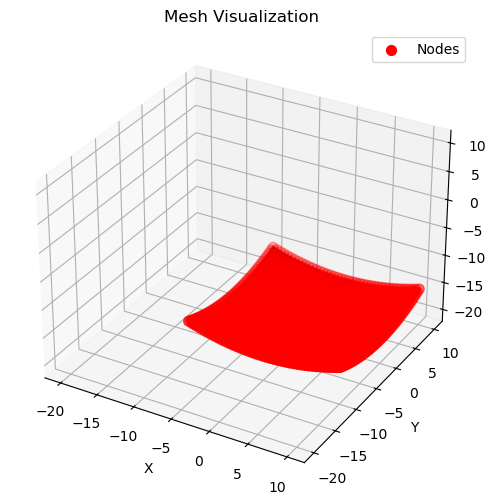

2024-09-24 01:16:35,876 - INFO - Mesh plotted and saved to mesh.png


TypeError: visualize_mesh_with_boundary_conditions() got an unexpected keyword argument 'plot_title'

In [24]:
# ------------------------------
# 9. Main Execution
# ------------------------------

def main():
    # Parameters
    flat_width = 20.0
    flat_height = 20.0
    depth = 3.0  # Small non-zero value
    frequency = 3.0  # Hz
    incident_wave_amplitude = 0.1
    c_p = 3000.0  # Primary wave speed
    c_s = 1600.0  # Secondary wave speed
    dt = 0.001  # Time step size
    total_time = 3.0  # Total simulation time
    element_size = 0.5
    time_shift = 0.3

    selected_nodes = [0, 10, 30, 40]  # Nodes to track during the simulation

    boundary_conditions = {
        'fixed_width': 1,          # Fixed boundary width
        'absorbing_width': 1,      # Absorbing boundary width
        'absorbing': {
            'damping_factor': 0.5     # Damping factor for absorbing boundary
        }
    }

    # Generate mesh
    points_3d, elements = generate_mesh((flat_width, flat_height), element_size)
    points_3d = create_valley(points_3d, flat_width, flat_height, depth)

    # Plot mesh
    plot_mesh(points_3d, elements, output_file="mesh.png")

    # Visualize mesh with boundary conditions
    visualize_mesh_with_boundary_conditions(
        points_3d, elements, boundary_conditions,
        flat_width, flat_height, plot_title="Initial Mesh with Boundary Conditions",
        output_file="mesh_with_bc.png"
    )

    # Plot incident wave
    plot_incident_wave(frequency, time_range=(0, total_time), time_step=dt, time_shift=time_shift, output_file="incident_wave.png")
    # Test the solver
    test_solver_1d(points_3d, boundary_conditions, incident_wave_amplitude, frequency, c_p, c_s, dt, total_time, time_shift)
    ANSWER = Input()
    if ANSWER == 'y':  
        # Time stepping solver
        displacement_history = time_stepping_solver_dynamic(
            build_system_sparse_numba,      # Function to build stiffness matrix
            points_3d,
            boundary_conditions,
            incident_wave_amplitude,
            frequency,
            c_p,
            c_s,
            dt,
            total_time,
            time_shift,
            selected_nodes,
            flat_width,
            flat_height,
            output_file="displacements.csv"
        )

        # Plot time histories
        plot_time_histories(
            displacement_history,
            selected_nodes,
            dt,
            output_file="time_histories.html"
        )

        # Extract node time histories (if needed)
        node_time_histories = extract_node_time_histories(displacement_history, selected_nodes)

        # Visualize results with slider
        visualize_results_with_slider(
            points_3d,
            displacement_history,
            elements,
            incident_wave_amplitude,
            dt,
            output_file="results_with_slider.html"
        )

if __name__ == "__main__":
    main()



In [22]:
import sympy as sp

def analytical_solution_1d(x, t, frequency, c_p):
    """
    Calculates the analytical solution for a 1D point source in a semi-infinite elastic medium.

    Args:
        x (float): Distance from the source.
        t (float): Time.
        frequency (float): Frequency of the source.
        c_p (float): Primary wave speed.

    Returns:
        float: Displacement at the given point and time.
    """

    # Define symbols
    x, t, omega, c_p = sp.symbols('x t omega c_p')

    # Fourier transform of the source
    source_fourier = 1 / (2 * sp.pi)

    # Green's function for the wave equation
    greens_function = sp.exp(-sp.I * omega * x / c_p) / (2 * sp.I * omega * c_p)

    # Inverse Fourier transform to get the displacement
    displacement_symbolic = sp.inverse_fourier_transform(source_fourier * greens_function, omega, t)

    # Substitute values and evaluate
    displacement_numeric = displacement_symbolic.subs({omega: 2 * sp.pi * frequency, c_p: c_p}).evalf(subs={x: x, t: t})

    return displacement_numeric

In [23]:
def test_solver_1d(points_3d, boundary_conditions, incident_wave_amplitude, frequency, c_p, c_s, dt, total_time, time_shift):
    """
    Tests the elastodynamic solver against an analytical solution for a 1D point source.

    Args:
        # ... (same arguments as the time_stepping_solver_dynamic function)

    Returns:
        None
    """

    # Extract 1D points and corresponding indices
    x = points_3d[:, 0]
    z = points_3d[:, 2]
    surface_indices = np.where(z == 0)[0]

    # Calculate analytical solution
    t = np.linspace(0, total_time, int(total_time / dt))
    analytical_solution = np.zeros((len(surface_indices), len(t)))
    for i, x_point in enumerate(x[surface_indices]):
        for j, t_val in enumerate(t):
            # Implement the analytical solution formula here
            # Use the analytical solution from sympy
            analytical_solution = np.array([analytical_solution_1d(x_point, t_val, frequency, c_p) for x_point in x[surface_indices] for t_val in t])
            analytical_solution = analytical_solution.reshape((len(surface_indices), len(t)))
    # Run numerical simulation
    numerical_solution = time_stepping_solver_dynamic(
        # ... (same arguments as the original function)
    )

    # Extract numerical solution for surface points
    numerical_surface_solution = np.array([numerical_solution[i][surface_indices] for i in range(len(numerical_solution))])

    # Compare analytical and numerical solutions
    error = np.linalg.norm(analytical_solution - numerical_surface_solution) / np.linalg.norm(analytical_solution)
    print(f"Error: {error:.4f}")

    # Plot comparison
    plt.figure()
    plt.plot(t, analytical_solution[0, :], label='Analytical')
    plt.plot(t, numerical_surface_solution[0, :], label='Numerical')
    plt.xlabel('Time')
    plt.ylabel('Displacement')
    plt.legend()
    plt.show()